<a href="https://colab.research.google.com/github/mehek-niwas/openvla-selfie/blob/main/openvla_inference_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OpenVLA Inference Demo

This notebook loads `openvla/openvla-7b` from HuggingFace, runs a single inference step on an image + instruction, and visualizes the resulting 7-DoF action vector `(Δx, Δy, Δz, Δroll, Δpitch, Δyaw, gripper)`.

**Runtime**: Go to `Runtime > Change runtime type > GPU` (A100 or L4 recommended; T4 works but is slow and may need 8-bit loading). The model is 7B params in bfloat16 (~15GB), so a free T4 (16GB) is borderline — use `load_in_8bit=True` if you hit OOM.

This is the actual HuggingFace-supported inference path (not a toy reimplementation) — `model.predict_action(...)` internally does exactly what we discussed: masks the vocabulary down to the 256 reused action-token IDs, runs the fixed 7-step autoregressive loop, and de-tokenizes bins back into continuous values using the training set's 1st/99th percentile ranges. We'll also peek at the raw token IDs manually so you can see that step explicitly.

In [ ]:
!pip install -q "transformers==4.40.1" "tokenizers==0.19.1" "timm==0.9.10" \
               sentencepiece accelerate Pillow datasets

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.7.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.1 which is incompatible.
gradio 6.24.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [ ]:
import torch
from transformers import AutoModelForVision2Seq, AutoProcessor

processor = AutoProcessor.from_pretrained("openvla/openvla-7b", trust_remote_code=True)
model = AutoModelForVision2Seq.from_pretrained(
    "openvla/openvla-7b",
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
    # attn_implementation="flash_attention_2",  # uncomment if you installed flash-attn in cell 4
).to("cuda:0").eval()

print(f"GPU mem used: {torch.cuda.memory_allocated() / 1e9:.1f} GB")
print(f"Llama backbone layers: {len(model.language_model.model.layers)}")
print(f"Hidden size: {model.language_model.config.hidden_size}")

print("Model loaded.")

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loaded. GPU mem used: 16.6 GB
Llama backbone layers: 32
Hidden size: 4096


## Load a sample image

Swap this URL for any tabletop/manipulation-style photo, or upload your own with `files.upload()` from `google.colab`.

Scene: corn_between_cups
Using instruction: put the yellow corn between the cups


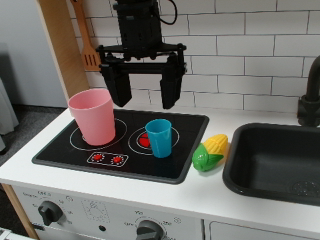

In [ ]:
from datasets import load_dataset

# Small public Bridge-style (WidowX) scene set — ~660 KB, 12 images, imagefolder format.
# Returns PIL images directly. Swap in any other PIL-image-serving HF dataset if you prefer.
ds = load_dataset("Sombit/v3la_eval_database_widowx", split="train", streaming=True)
example = next(iter(ds))

image = example["image"].convert("RGB")    # PIL image (320x240)

# The scene label encodes the task; map to a natural-language instruction.
# Override `instruction` below with any known-good Bridge task if you want.
label_names = ["corn_between_cups", "stack_pink_blue_cup"]
scene_instructions = {
    "corn_between_cups":   "put the yellow corn between the cups",
    "stack_pink_blue_cup": "stack the pink cup on the blue cup",
}
scene = label_names[example["label"]]
instruction = scene_instructions[scene]    # e.g. "put the yellow corn between the cups"

print("Scene:", scene)
print("Using instruction:", instruction)
image  # displays inline

## Run inference

`predict_action` expects a prompt in the exact format OpenVLA was fine-tuned on, and an `unnorm_key` telling it which dataset's action statistics (percentile ranges) to de-normalize with. `bridge_orig` is one of the Open X-Embodiment sub-datasets it was trained on — swap it if you want a different embodiment's stats.

In [ ]:
instruction = "pick up the corn"
prompt = f"In: What action should the robot take to {instruction}?\nOut:"

inputs = processor(prompt, image).to(device, dtype=torch.bfloat16)

action = model.predict_action(**inputs, unnorm_key="bridge_orig", do_sample=False)

labels = ["dx", "dy", "dz", "droll", "dpitch", "dyaw", "gripper"]
for name, val in zip(labels, action):
    print(f"{name:8s}: {val: .4f}")

dx      :  0.0193
dy      : -0.0215
dz      : -0.0127
droll   :  0.0280
dpitch  : -0.0597
dyaw    : -0.0323
gripper :  0.9961


## Peeking at the raw action tokens

This replicates what `predict_action` does under the hood, but stops before de-normalization so you can see the actual reused vocabulary IDs and bin indices — the part we talked through conceptually.

In [ ]:
with torch.no_grad():
    generated_ids = model.generate(**inputs, max_new_tokens=7, do_sample=False)

# the last 7 generated tokens correspond to the 7 action dimensions
action_token_ids = generated_ids[0, -7:].tolist()
vocab_size = processor.tokenizer.vocab_size          # 32000 for Llama-2 tokenizer
n_bins = 256
bin_ids = [vocab_size - tok_id - 1 for tok_id in action_token_ids]  # OpenVLA's actual reverse mapping

print("Raw token IDs   :", action_token_ids)
print("Decoded bin idx :", bin_ids, "(each in [0, 255])")

Raw token IDs   : [31893, 31946, 31938, 31887, 31868, 31858, 31864]
Decoded bin idx : [106, 53, 61, 112, 131, 141, 135] (each in [0, 255])


## Visualize the action

Two views since there's no robot to actually move:
1. A bar chart of all 7 action dimensions.
2. An arrow overlaid on the image showing the predicted (dx, dy) as a 2D direction — a rough, illustrative proxy for "which way the end-effector would move," not a calibrated projection.

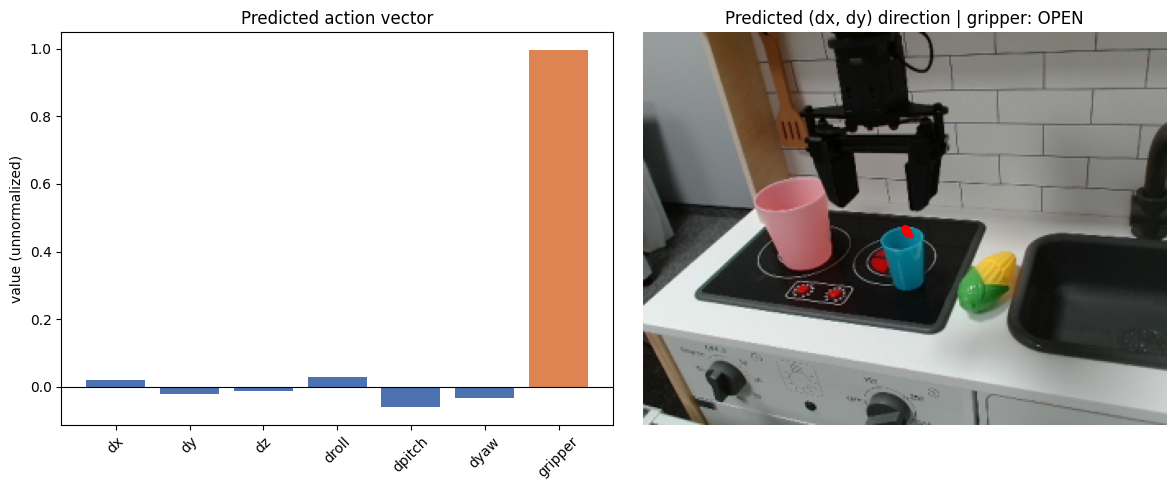

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- bar chart ---
axes[0].bar(labels, action, color=["#4C72B0"]*6 + ["#DD8452"])
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Predicted action vector")
axes[0].set_ylabel("value (unnormalized)")
axes[0].tick_params(axis="x", rotation=45)

# --- arrow overlay on the image ---
axes[1].imshow(image)
h, w = image.size[1], image.size[0]
cx, cy = w / 2, h / 2
scale = min(w, h) * 1.5   # purely visual scaling, arbitrary units -> pixels
dx, dy = action[0], action[1]
axes[1].annotate(
    "", xy=(cx + dx * scale, cy - dy * scale), xytext=(cx, cy),
    arrowprops=dict(arrowstyle="->", color="red", linewidth=3),
)
axes[1].scatter([cx], [cy], color="red", s=30)
gripper_state = "CLOSE" if action[-1] < 0.5 else "OPEN"
axes[1].set_title(f"Predicted (dx, dy) direction | gripper: {gripper_state}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Notes

- Since there's no real robot/camera loop here, this is a single open-loop prediction from one static image — in a real deployment this would run at 3–5Hz, re-observing the scene after each action and re-predicting.
- Try changing `instruction` and re-running just the inference + visualization cells to see how the predicted direction changes.
- `dz`, `droll`, `dpitch`, `dyaw` aren't visualized spatially here since that needs a proper 3D/camera-calibrated projection — the bar chart on the left is the honest view of all 7 dimensions.